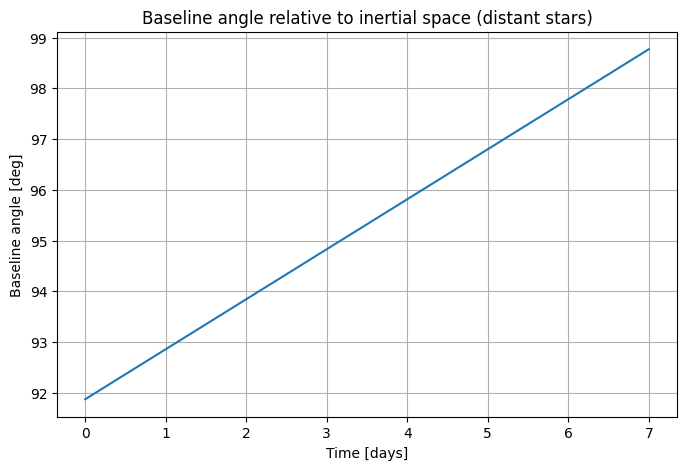

Baseline angle change over 7 days: 6.89852 deg


In [2]:
import numpy as np
import matplotlib.pyplot as plt

# --- Constants ---
AU = 1.496e11       # meters
n_days = 7          # simulation duration
dt = 0.01           # days per timestep
t = np.arange(0, n_days+dt, dt)  # time array in days
mu_sun = 1.327e20  # m^3/s^2, solar gravitational parameter

# --- Satellite orbits ---
# Slightly different semi-major axes to slow down angular rotation
a1 = AU            # Satellite 1
a2 = AU * 1.00005  # Satellite 2 slightly higher → slower orbit

# Function: mean motion in rad/day
def mean_motion(a):
    n = np.sqrt(mu_sun / a**3) * (86400)  # convert rad/s to rad/day
    return n

n1 = mean_motion(a1)
n2 = mean_motion(a2)

# Initial phase offsets (set baseline ~1e10 m)
baseline_length = 1e10  # meters
delta_phi = baseline_length / AU  # radians
phi1_0 = 0.0
phi2_0 = phi1_0 + delta_phi

# --- Satellite positions over time ---
x1 = a1 * np.cos(n1 * t + phi1_0)
y1 = a1 * np.sin(n1 * t + phi1_0)

x2 = a2 * np.cos(n2 * t + phi2_0)
y2 = a2 * np.sin(n2 * t + phi2_0)

# --- Baseline vector angle relative to inertial x-axis ---
dx = x2 - x1
dy = y2 - y1
baseline_angle_deg = np.degrees(np.arctan2(dy, dx))

# --- Plot ---
plt.figure(figsize=(8,5))
plt.plot(t, baseline_angle_deg)
plt.xlabel("Time [days]")
plt.ylabel("Baseline angle [deg]")
plt.title("Baseline angle relative to inertial space (distant stars)")
plt.grid(True)
plt.show()

# --- Optional: check variation ---
print(f"Baseline angle change over {n_days} days: {baseline_angle_deg[-1]-baseline_angle_deg[0]:.5f} deg")
